<a href="https://colab.research.google.com/github/gabrielbarata/MVP-machine-learning/blob/main/MVP_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
  from pathos.multiprocessing import ProcessingPool as Pool
except ModuleNotFoundError as e:
  !pip install pathos
  from pathos.multiprocessing import ProcessingPool as Pool

In [ ]:
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split

In [ ]:
import gc
import ctypes
import tensorflow as tf

def clear_memory():
    tf.keras.backend.clear_session()
    gc.collect()
    ctypes.CDLL('libc.so.6').malloc_trim(0)

tot_cpu = os.cpu_count()
print(f"Número de núcleos: {tot_cpu}")

Número de núcleos: 2


In [ ]:
# SHAPE_X = 32
SHAPE_X = 64

In [ ]:
# import tensorflow as tf
# from keras import layers, models
# import numpy as np
# from pathlib import Path

# # 1. Carregar e preparar o dataset MNIST
# mnist = tf.keras.datasets.mnist
# (x_train, y_train), (x_test, y_test) = mnist.load_data()

# x_raw = np.concat([x_train,x_test])
# y_raw = np.concat([y_train,y_test])


# class_names = {int(i):str(i) for i in np.unique(y_raw)}

# dataset_dir = Path("dataset_mnist").resolve()


# print(f"x_train: {len(x_raw)} x {x_raw[0].shape}, y_train: {y_raw.shape}")
# print(f"Class Names: {class_names}")

In [ ]:
import kagglehub
import os
from pathlib import Path

path = kagglehub.dataset_download("fernando2rad/brain-tumor-mri-images-30-classes" )
print("Dataset baixado em:", path)

dataset_dir = Path("dataset_brain_tumor").resolve()


100%|██████████| 478M/478M [00:26<00:00, 18.8MB/s]

Extracting files...


Dataset baixado em: /root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-30-classes/versions/1


In [ ]:
# import kagglehub
# import os
# from pathlib import Path

# path = kagglehub.dataset_download("vijaykumar1799/face-mask-detection")
# path = f"{path}/Dataset"
# print("Path to dataset files:", path)

# dataset_dir = Path("dataset_face_mask").resolve()


In [ ]:

from PIL import Image

# Função de tarefa sem dependências externas
def process_load_task(args):
    img_path, label = args
    try:
        # Leitura inline (não depende de read_image_helper)
        img = np.array(Image.open(img_path).convert('L'))  #
        # gc.collect()
        # img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            return img, label
    except:
        pass
    # gc.collect()
    return None

def load_kaggle(base_path):
    categories = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    label_map = {category: i for i, category in enumerate(categories)}

    # Create a reverse map for class names
    class_names = {i: category for category, i in label_map.items()}

    print(f"Encontradas {len(categories)} classes. Preparando lista de tarefas...")

    tasks = []
    for category in categories:
        folder_path = os.path.join(base_path, category)
        label = label_map[category]
        for img_name in os.listdir(folder_path):
            tasks.append((os.path.join(folder_path, img_name), label))

    print(f"Carregando {len(tasks)} imagens em paralelo...")
    with Pool(nodes = tot_cpu) as pool:
        results = pool.map(process_load_task, tasks)
    # results = list(map(process_load_task, tasks))

    valid_results = [r for r in results if r is not None]
    x = [r[0] for r in valid_results]
    y = np.array([r[1] for r in valid_results])

    print(f"x_train: {len(x)} x {x[0].shape}, y_train: {y.shape}")
    print(f"Class Names: {class_names}")

    return x, y, class_names

x_raw, y_all, class_names = load_kaggle(path)



Encontradas 30 classes. Preparando lista de tarefas...
Carregando 11300 imagens em paralelo...
x_train: 11300 x (512, 512), y_train: (11300,)
Class Names: {0: 'Astrocytoma T1', 1: 'Astrocytoma T1C+', 2: 'Astrocytoma T2', 3: 'Ependymoma T1', 4: 'Ependymoma T1C+', 5: 'Ependymoma T2', 6: 'Glioma T1', 7: 'Glioma T1C+', 8: 'Glioma T2', 9: 'Hemangiopericytoma T1', 10: 'Hemangiopericytoma T1C+', 11: 'Hemangiopericytoma T2', 12: 'Meningioma T1', 13: 'Meningioma T1C+', 14: 'Meningioma T2', 15: 'Neurocytoma T1', 16: 'Neurocytoma T1C+', 17: 'Neurocytoma T2', 18: 'Normal T1', 19: 'Normal T1C+', 20: 'Normal T2', 21: 'Oligodendroglioma T1', 22: 'Oligodendroglioma T1C+', 23: 'Oligodendroglioma T2', 24: 'Other T1', 25: 'Other T1C+', 26: 'Other T2', 27: 'Schwannoma T1', 28: 'Schwannoma T1C+', 29: 'Schwannoma T2'}


In [ ]:
def resize_dataset_parallel(x_list, img_size):
    print(f"Redimensionando {len(x_list)} imagens para {img_size}...")


    def local_resize(img):
        return cv2.resize(img, img_size)

    with Pool(nodes = tot_cpu) as pool:
        results = pool.map(local_resize, x_list)

    # results = list(map(local_resize, x_list))

    results = np.array(results)

    print(f"resize_dataset_parallel: {results.shape}")

    return results

d0_max = max([i.shape[0] for i in x_raw])
d1_max = max([i.shape[1] for i in x_raw])

x_raw = resize_dataset_parallel(x_raw, img_size=(d0_max, d1_max))
clear_memory()

x_all = resize_dataset_parallel(x_raw, img_size=(SHAPE_X, SHAPE_X))

clear_memory()

Redimensionando 11300 imagens para (512, 512)...
resize_dataset_parallel: (11300, 512, 512)
Redimensionando 11300 imagens para (64, 64)...
resize_dataset_parallel: (11300, 64, 64)




original




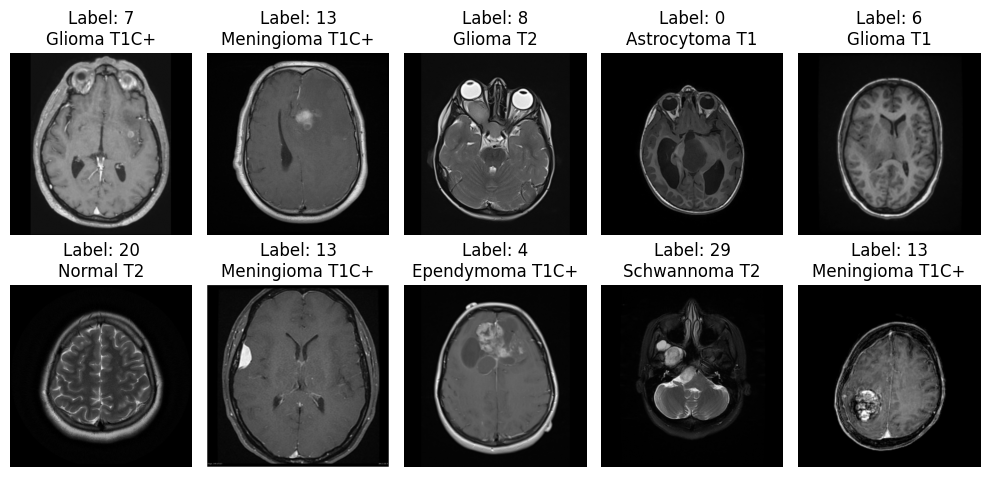



resized




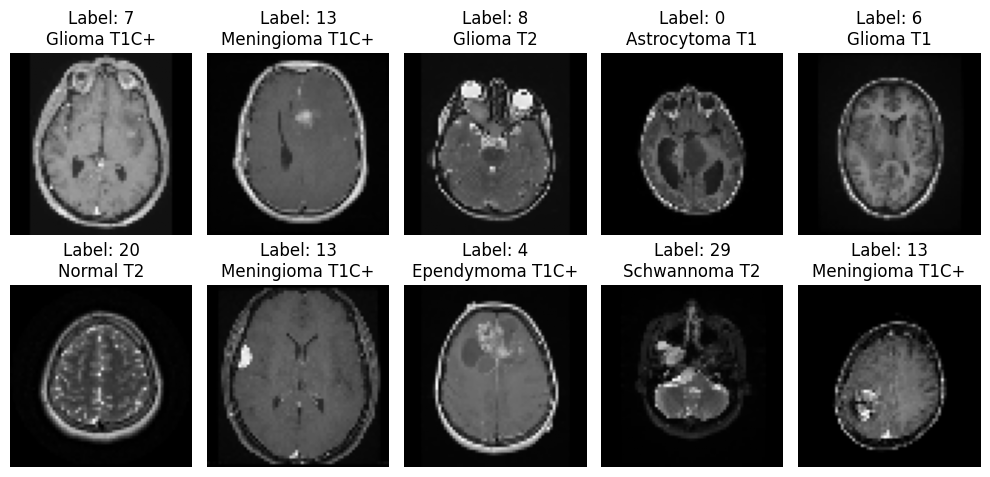

In [ ]:
import matplotlib.pyplot as plt

def display_dataset(x, y, idxs=None):
  plt.figure(figsize=(10, 5))
  if idxs is None:
      idxs = np.random.choice(len(x), 10, replace=False)
  for n, i in enumerate(idxs):
      plt.subplot(2, 5, n + 1)
      plt.imshow(x[i], cmap='gray')
      plt.title(f"Label: {y[i]}\n{class_names[y[i]]}")
      plt.axis('off')

  plt.tight_layout()
  plt.show()


idxs = np.random.choice(len(x_raw), 10, replace=False)
print("\n\noriginal\n\n")
display_dataset(x_raw, y_all,idxs)
print("\n\nresized\n\n")
display_dataset(x_all, y_all,idxs)


In [ ]:
def remove_duplicates_and_sync(x_data, y_data):
    unique_hashes = set()
    x_unique_list = []
    y_unique_list = []

    for i in range(len(x_data)):
        img = x_data[i]
        label = y_data[i]

        img_hash = img.tobytes()

        if img_hash not in unique_hashes:
            unique_hashes.add(img_hash)
            x_unique_list.append(img)
            y_unique_list.append(label)

    x_unique = np.array(x_unique_list)
    y_unique = np.array(y_unique_list)

    print(f"Original: {len(x_data)} amostras. Após remover {len(x_data) - len(x_unique)} duplicatas: {len(x_unique)} amostras.")
    print(f"remove_duplicates_and_sync: {x_unique.shape} {y_unique.shape}")

    return x_unique, y_unique


x_unique, y_unique = remove_duplicates_and_sync(x_all, y_all)



Original: 11300 amostras. Após remover 1865 duplicatas: 9435 amostras.
remove_duplicates_and_sync: (9435, 64, 64) (9435,)


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(
    x_unique, y_unique, test_size=0.3, random_state=42, shuffle=True
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
)

print(f"\nFormato final:")
print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_val: {x_val.shape}, y_val: {y_val.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")


Formato final:
x_train: (6604, 64, 64), y_train: (6604,)
x_val: (1415, 64, 64), y_val: (1415,)
x_test: (1416, 64, 64), y_test: (1416,)


In [ ]:
def print_value_and_shape(val):
  print()
  print(val)
  print()
  print("shape:",val.shape)
  print()

In [ ]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np
import pandas as pd

def get_balanced_dataset(x, y):

  n_samples, *n_features = x.shape

  x_flat = x.reshape((n_samples, np.prod(n_features)))

  ros = RandomOverSampler(random_state=42)
  x_balanced, y_balanced = ros.fit_resample(x_flat, y)

  x_balanced = x_balanced.reshape((-1, *n_features))

  df_counts = pd.DataFrame({
      'original': pd.Series(y).value_counts(),
      'balanceado': pd.Series(y_balanced).value_counts()
  }).sort_index()

  print("\nDataFrame de contagens:\n")
  print(df_counts)


  return x_balanced, y_balanced


x_train, y_train = get_balanced_dataset(x_train, y_train)
x_val, y_val = get_balanced_dataset(x_val, y_val)
x_test, y_test = get_balanced_dataset(x_test, y_test)
clear_memory()



DataFrame de contagens:

    original  balanceado
0        256         629
1        269         629
2        197         629
3        183         629
4        218         629
5        173         629
6        243         629
7        278         629
8        174         629
9         67         629
10       118         629
11        53         629
12       431         629
13       629         629
14       260         629
15       109         629
16       153         629
17       105         629
18       287         629
19       177         629
20       238         629
21       133         629
22       133         629
23        84         629
24       255         629
25       475         629
26       207         629
27       198         629
28       325         629
29       176         629

DataFrame de contagens:

    original  balanceado
0         61         145
1         74         145
2         34         145
3         39         145
4         48         145
5         28         14

In [ ]:
import numpy as np

def check_data_overlap(x_train_data, x_test_data):

    train_hashes = set()
    for img in x_train_data:
        train_hashes.add(img.tobytes())

    test_hashes = set()
    for img in x_test_data:
        test_hashes.add(img.tobytes())

    overlap = train_hashes.intersection(test_hashes)

    if len(overlap) > 0:
        print(f"ATENÇÃO: Foram encontrados {len(overlap)} elementos idênticos entre os conjuntos.")
    else:
        print("Nenhuma sobreposição encontrada entre os conjuntos.")

# Chamando a função com os dados existentes no kernel
check_data_overlap(x_train, x_val)
check_data_overlap(x_train, x_test)
check_data_overlap(x_val, x_test)


Nenhuma sobreposição encontrada entre os conjuntos.
Nenhuma sobreposição encontrada entre os conjuntos.
Nenhuma sobreposição encontrada entre os conjuntos.


In [ ]:

all_xy_arrays = {
    "x_all": x_all,

    "x_train": x_train,
    "x_val": x_val,
    "x_test": x_test,

    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
}

all_xy_arrays = {f"{k}_{SHAPE_X}x{SHAPE_X}":v for k,v in all_xy_arrays.items()}

all_xy_arrays = {
    "class_names":np.array(class_names),
    "x_raw": x_raw,
    "y_all": y_all,
    **all_xy_arrays
}

for key, value in all_xy_arrays.items():
    if isinstance(value, list):
        print(f"Key: {key}, Type: {type(value)}, Length: {len(value)}")
        if len(value) > 0 and hasattr(value[0], 'shape'):
            print(f"  Example element shape: {value[0].shape}")
    else:
        print(f"Key: {key}, Shape: {value.shape}")

clear_memory()

Key: class_names, Shape: ()
Key: x_raw, Shape: (11300, 512, 512)
Key: y_all, Shape: (11300,)
Key: x_all_64x64, Shape: (11300, 64, 64)
Key: x_train_64x64, Shape: (18870, 64, 64)
Key: x_val_64x64, Shape: (4350, 64, 64)
Key: x_test_64x64, Shape: (3900, 64, 64)
Key: y_train_64x64, Shape: (18870,)
Key: y_val_64x64, Shape: (4350,)
Key: y_test_64x64, Shape: (3900,)


In [ ]:
import os
import numpy as np


dataset_dir.mkdir(exist_ok=True)


for key, value in all_xy_arrays.items():
    filename = dataset_dir/f"{key}.npy"
    clear_memory()
    np.save(filename, value)
    clear_memory()
    print(f"Salvo '{key}' em '{filename}' com shape {value.shape}")

Salvo 'class_names' em '/content/dataset_brain_tumor/class_names.npy' com shape ()
Salvo 'x_raw' em '/content/dataset_brain_tumor/x_raw.npy' com shape (11300, 512, 512)
Salvo 'y_all' em '/content/dataset_brain_tumor/y_all.npy' com shape (11300,)
Salvo 'x_all_64x64' em '/content/dataset_brain_tumor/x_all_64x64.npy' com shape (11300, 64, 64)
Salvo 'x_train_64x64' em '/content/dataset_brain_tumor/x_train_64x64.npy' com shape (18870, 64, 64)
Salvo 'x_val_64x64' em '/content/dataset_brain_tumor/x_val_64x64.npy' com shape (4350, 64, 64)
Salvo 'x_test_64x64' em '/content/dataset_brain_tumor/x_test_64x64.npy' com shape (3900, 64, 64)
Salvo 'y_train_64x64' em '/content/dataset_brain_tumor/y_train_64x64.npy' com shape (18870,)
Salvo 'y_val_64x64' em '/content/dataset_brain_tumor/y_val_64x64.npy' com shape (4350,)
Salvo 'y_test_64x64' em '/content/dataset_brain_tumor/y_test_64x64.npy' com shape (3900,)


In [ ]:
import os
import numpy as np
from pathlib import Path

# Ensure dataset_dir is defined, if not already in the kernel
# In this case, it is already defined as Path('dataset_brain_tumor').resolve()

all_xy_arrays = {}

print(f"Recriando all_xy_arrays a partir de: {dataset_dir}")
for file_path in dataset_dir.glob("*"):

  key_name = file_path.stem
  try:
      clear_memory()
      loaded_data = np.load(file_path, allow_pickle=True)
      clear_memory()
      all_xy_arrays[key_name] = loaded_data
      print(f"Carregado '{key_name}' com shape {loaded_data.shape}")
  except Exception as e:
      print(f"Erro ao carregar '{file_path}': {e}")

print("\nConteúdo do all_xy_arrays:")
for key, value in all_xy_arrays.items():
    print(f"  '{key}': {type(value)} com shape {value.shape}")

Recriando all_xy_arrays a partir de: /content/dataset_brain_tumor
Carregado 'y_all' com shape (11300,)
Carregado 'class_names' com shape ()
Carregado 'x_raw' com shape (11300, 512, 512)
Carregado 'y_val_64x64' com shape (4350,)
Carregado 'x_train_64x64' com shape (18870, 64, 64)
Carregado 'x_val_64x64' com shape (4350, 64, 64)
Carregado 'x_all_64x64' com shape (11300, 64, 64)
Carregado 'y_test_64x64' com shape (3900,)
Carregado 'x_test_64x64' com shape (3900, 64, 64)
Carregado 'y_train_64x64' com shape (18870,)

Conteúdo do all_xy_arrays:
  'y_all': <class 'numpy.ndarray'> com shape (11300,)
  'class_names': <class 'numpy.ndarray'> com shape ()
  'x_raw': <class 'numpy.ndarray'> com shape (11300, 512, 512)
  'y_val_64x64': <class 'numpy.ndarray'> com shape (4350,)
  'x_train_64x64': <class 'numpy.ndarray'> com shape (18870, 64, 64)
  'x_val_64x64': <class 'numpy.ndarray'> com shape (4350, 64, 64)
  'x_all_64x64': <class 'numpy.ndarray'> com shape (11300, 64, 64)
  'y_test_64x64': <clas

In [ ]:
shape_str = f"_{SHAPE_X}x{SHAPE_X}"

x_raw = all_xy_arrays['x_raw']
x_all = all_xy_arrays[f'x_all{shape_str}']
y_all = all_xy_arrays['y_all']

x_train = all_xy_arrays[f'x_train{shape_str}']
x_val = all_xy_arrays[f'x_val{shape_str}']
x_test = all_xy_arrays[f'x_test{shape_str}']

y_train = all_xy_arrays[f'y_train{shape_str}']
y_val = all_xy_arrays[f'y_val{shape_str}']
y_test = all_xy_arrays[f'y_test{shape_str}']

class_names = all_xy_arrays["class_names"].item()

print("Variáveis recriadas individualmente:")
print(f"  x_raw shape: {x_raw.shape}")
print(f"  x_all shape: {x_all.shape}")
print(f"  y_all shape: {y_all.shape}")
print(f"  x_train shape: {x_train.shape}")
print(f"  x_test shape: {x_test.shape}")
print(f"  x_val shape: {x_val.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  y_val shape: {y_val.shape}")
print(f"  class_names: {class_names}")
clear_memory()

Variáveis recriadas individualmente:
  x_raw shape: (11300, 512, 512)
  x_all shape: (11300, 64, 64)
  y_all shape: (11300,)
  x_train shape: (18870, 64, 64)
  x_test shape: (3900, 64, 64)
  x_val shape: (4350, 64, 64)
  y_train shape: (18870,)
  y_test shape: (3900,)
  y_val shape: (4350,)
  class_names: {0: 'Astrocytoma T1', 1: 'Astrocytoma T1C+', 2: 'Astrocytoma T2', 3: 'Ependymoma T1', 4: 'Ependymoma T1C+', 5: 'Ependymoma T2', 6: 'Glioma T1', 7: 'Glioma T1C+', 8: 'Glioma T2', 9: 'Hemangiopericytoma T1', 10: 'Hemangiopericytoma T1C+', 11: 'Hemangiopericytoma T2', 12: 'Meningioma T1', 13: 'Meningioma T1C+', 14: 'Meningioma T2', 15: 'Neurocytoma T1', 16: 'Neurocytoma T1C+', 17: 'Neurocytoma T2', 18: 'Normal T1', 19: 'Normal T1C+', 20: 'Normal T2', 21: 'Oligodendroglioma T1', 22: 'Oligodendroglioma T1C+', 23: 'Oligodendroglioma T2', 24: 'Other T1', 25: 'Other T1C+', 26: 'Other T2', 27: 'Schwannoma T1', 28: 'Schwannoma T1C+', 29: 'Schwannoma T2'}


In [ ]:
def normalize_data(x):
    x = x.astype('float32')
    _, *axis_ = range(len(x.shape))
    axis_ = tuple(axis_)

    mean = np.mean(x, axis=axis_, keepdims=True)
    std = np.std(x, axis=axis_, keepdims=True)

    std = np.where(std == 0, 1e-7, std)

    x_norm = (x - mean) / std

    return x_norm


x_all_norm = normalize_data(x_all)

_, *axis_ = range(len(x_all_norm.shape))
axis_ = tuple(axis_)

print("\n\noriginal\n\n")
print("mean")
print_value_and_shape(np.mean(x_all, axis=axis_))
print("std")
print_value_and_shape(np.std(x_all, axis=axis_))

print("\n\nnormalizado\n\n")
print("mean")
print_value_and_shape(np.mean(x_all_norm, axis=axis_))
print("std")
print_value_and_shape(np.std(x_all_norm, axis=axis_))



original


mean

[83.14379883 19.57104492 43.97070312 ... 35.08227539 48.07202148
 39.38110352]

shape: (11300,)

std

[74.16810822 31.76744771 52.45223014 ... 50.3665453  61.01135299
 52.58962796]

shape: (11300,)



normalizado


mean

[ 3.7252903e-09 -2.9802322e-08 -7.4505806e-09 ... -7.4505806e-09
  7.4505806e-09  7.4505806e-09]

shape: (11300,)

std

[1.        1.        1.0000001 ... 1.        1.        1.       ]

shape: (11300,)



In [ ]:


def get_current_data_norm():

  x_train_norm = normalize_data(x_train)
  x_val_norm = normalize_data(x_val)
  x_test_norm = normalize_data(x_test)
  x_all_norm = normalize_data(x_all)

  return x_train_norm, x_val_norm, x_test_norm, x_all_norm




def get_current_data_cnn():

  x_train_norm, x_val_norm, x_test_norm, x_all_norm = get_current_data_norm()

  x_train_cnn = x_train_norm[..., None]
  x_val_cnn = x_val_norm[..., None]
  x_test_cnn = x_test_norm[..., None]
  x_all_cnn = x_all_norm[..., None]

  return x_train_cnn, x_val_cnn, x_test_cnn, x_all_cnn




def get_current_data_transfer(preprocess_input):

  x_train_transfer = np.repeat(x_train[..., None], 3, -1)
  x_val_transfer = np.repeat(x_val[..., None], 3, -1)
  x_test_transfer = np.repeat(x_test[..., None], 3, -1)
  x_all_transfer = np.repeat(x_all[..., None], 3, -1)

  x_train_transfer = preprocess_input(x_train_transfer.astype('float32'))
  x_val_transfer = preprocess_input(x_val_transfer.astype('float32'))
  x_test_transfer = preprocess_input(x_test_transfer.astype('float32'))
  x_all_transfer = preprocess_input(x_all_transfer.astype('float32'))

  return x_train_transfer, x_val_transfer, x_test_transfer, x_all_transfer


In [ ]:
_, *x_dims = x_train.shape
num_classes = int(y_train.max()) + 1
x_dims, num_classes

([64, 64], 30)

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
        print("TensorFlow configurado para usar GPU.")
    except RuntimeError as e:
        print(e)
else:
    print("Nenhuma GPU detectada. Vá em 'Ambiente de execução' -> 'Alterar tipo de ambiente de execução' e selecione uma GPU (T4, L4, etc).")

1 Physical GPUs, 1 Logical GPUs
TensorFlow configurado para usar GPU.


In [ ]:
import tensorflow as tf
import keras
from keras import layers, models, Input
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam, SGD
from pathlib import Path
from numba import cuda

def plot_model(model):
  return keras.utils.plot_model(model, expand_nested=True, show_shapes=True, show_layer_activations=True)

def show_model(model):
    def save_str(x):
      Path("model.txt").write_text(str(x))
    model.summary(print_fn=save_str)
    plot_model(model)


def get_best_model(x_val_inp, x_test_inp):
  model = models.load_model(checkpoint_filepath)
  show_model(model)
  print("validação")
  eval(model, x_val_inp, y_val)
  print()
  print()
  print("teste")
  eval(model, x_test_inp, y_test)
  return model

def eval(model, x_inp, y_inp):
  loss, acc = model.evaluate(x_inp, y_inp)
  print(f"\nAcurácia da CNN no conjunto: {acc:.4f}")

checkpoint_filepath = Path('best_model_cnn.keras')

def get_model_checkpoint_callback(checkpoint_filepath:Path):

  model_checkpoint_callback = ModelCheckpoint(
      filepath=checkpoint_filepath,
      save_best_only=True,
      monitor='val_accuracy',
      mode='max',
  )
  reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.2,
                                patience=50, min_lr=0.0001, verbose=1)

  return model_checkpoint_callback, reduce_lr

if not checkpoint_filepath.exists():
  model_checkpoint_callback, reduce_lr = get_model_checkpoint_callback(checkpoint_filepath)


In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, save_path=None):
  fig = plt.figure(figsize=(12, 5))
  max_acc = max(history.history['val_accuracy'])
  min_loss = min(history.history['val_loss'])
  plt.suptitle(f"Max Val Acc: {max_acc:.4f} | Min Val Loss: {min_loss:.4f}")

  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)

  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  plt.tight_layout(rect=[0, 0.03, 1, 0.95])

  if save_path:
    plt.savefig(save_path)
    plt.close()
  else:
    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def get_confusion_matrix_normalized(model, current_x_test):
  y_pred_probs = model.predict(current_x_test)
  y_pred = np.argmax(y_pred_probs, axis=1)

  cm = confusion_matrix(y_test, y_pred)

  row_sums = cm.sum(axis=1)
  cm_normalized = cm.astype('float') / (row_sums[:, np.newaxis] + 1e-8)

  cm_normalized = cm_normalized * 100

  return cm_normalized



def plot_confusion_matrix(cm_normalized):

  fig, ax = plt.subplots(figsize=(15, 15))
  disp = ConfusionMatrixDisplay(
      confusion_matrix=cm_normalized,
      display_labels=list(class_names.values())
  )
  disp.plot(
      cmap=plt.cm.Blues,
      ax=ax,
      xticks_rotation='vertical',
      values_format='.0f',
      text_kw={"fontsize": 8}
  )
  plt.title('Normalized Confusion Matrix (Accuracy per Class - Percentage)', fontsize=14)
  plt.xlabel('Predicted label', fontsize=12)
  plt.ylabel('True label', fontsize=12)
  plt.show()



def get_min_acc_class(cm_normalized):
  class_acc = np.diag(cm_normalized)

  max_acc_idx = np.argmax(class_acc)
  min_acc_idx = np.argmin(class_acc)

  max_acc_class_name = class_names[max_acc_idx]
  max_acc = class_acc[max_acc_idx]
  min_acc_class_name = class_names[min_acc_idx]
  min_acc = class_acc[min_acc_idx]

  print(f"Classe com maior acurácia: {max_acc_class_name} ({max_acc:.2f}%)")
  print(f"Classe com menor acurácia: {min_acc_class_name} ({min_acc:.2f}%)")
  print(f"média das acurácias por classe: {class_acc.mean():.2f}%")
  print(f"desvio padrão das acurácias por classe: {class_acc.std():.2f}%")

  return min_acc_idx, min_acc_class_name, min_acc


def plot_class_acc_distribution(cm_normalized):
  class_acc = np.diag(cm_normalized)

  plt.figure(figsize=(15, 7))
  plt.bar(list(class_names.values()), class_acc, color='skyblue')
  plt.xlabel('Classes')
  plt.ylabel('Acurácia (%)')
  plt.title('Acurácia por Classe')
  plt.xticks(rotation=90, fontsize=8)
  plt.tight_layout()
  plt.show()


def show_min_acc_distribution(cm_normalized, min_acc_idx, min_acc_class_name, min_acc):
  confused_row = cm_normalized[min_acc_idx]

  confused_row_new = cm_normalized[min_acc_idx].copy()

  confused_row_new[min_acc_idx] = 0

  most_confused_idx = np.argmax(confused_row_new)

  most_confused_class_name = class_names[most_confused_idx]
  confusion_percentage = confused_row[most_confused_idx]

  print(f"A classe '{min_acc_class_name}' (com {min_acc:.2f}% de acurácia) está se confundindo mais com '{most_confused_class_name}', com {confusion_percentage:.2f}% dos casos.")

  bar_colors = ['lightcoral'] * len(class_names)
  for i, class_name_val in class_names.items():
      if class_name_val == min_acc_class_name:
          bar_colors[i] = 'skyblue'
          break

  plt.figure(figsize=(15, 7))
  plt.bar(list(class_names.values()), confused_row, color=bar_colors)
  plt.xlabel('Classes Preditas')
  plt.ylabel('Percentual de Confusão (%)')
  plt.title(f"Confusão da Classe '{min_acc_class_name}' com Outras Classes")
  plt.xticks(rotation=90, fontsize=8)
  plt.tight_layout()
  plt.show()

In [ ]:
import tensorflow as tf
from keras import layers, models, Input
import numpy as np

def get_heatmap_model(model, x_inp):
    gap_layer = None
    gap_idx = None
    for idx, layer in enumerate(model.layers):
        if isinstance(layer, (layers.GlobalAveragePooling2D, layers.GlobalMaxPooling2D)):
            gap_layer = layer
            gap_idx = idx
            break
    if gap_idx is None:
        raise ValueError("Nenhuma camada GlobalAveragePooling2D/GlobalMaxPooling2D encontrada.")
    if gap_idx == 0:
        raise ValueError("A camada de pooling é a primeira camada do modelo.")

    pre_pool_layer = model.layers[gap_idx - 1]

    dense_layers = [layer for layer in model.layers if isinstance(layer, layers.Dense)]
    if not dense_layers:
        raise ValueError("Nenhuma camada Dense encontrada.")

    heatmap_input_tensor = model.input

    base_model_for_heatmap = models.Model(inputs=heatmap_input_tensor, outputs=pre_pool_layer.output)
    x = base_model_for_heatmap(heatmap_input_tensor)

    for i, dense in enumerate(dense_layers):
        kernel, bias = dense.get_weights()
        out_dim = kernel.shape[1]
        kernel_4d = np.reshape(kernel, (1, 1, kernel.shape[0], out_dim))

        activation = dense.activation
        if i == len(dense_layers) - 1:
            activation = tf.keras.activations.linear

        conv = layers.Conv2D(
            out_dim, (1, 1),
            use_bias=True,
            kernel_initializer=tf.constant_initializer(kernel_4d),
            bias_initializer=tf.constant_initializer(bias),
            activation=activation,
            trainable=False,
            name=f'spatial_dense_{i}'
        )
        x = conv(x)

    probs = model(heatmap_input_tensor)

    heatmap_model = models.Model(inputs=heatmap_input_tensor, outputs=[x, probs], name='heatmap_all_classes')
    print("saidas:", [i.shape for i in heatmap_model(x_inp[0][None,...])])
    return heatmap_model




In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def display_heatmaps_line(idx, x_norm_data, x_raw_data, y_labels, heatmap_model, n_display_probs=5):
    img_norm = x_norm_data[idx]

    img_tensor = img_norm[None,...]

    all_heatmaps, probs = heatmap_model(img_tensor)
    all_heatmaps = all_heatmaps[0].numpy()
    probs_flat = probs[0].numpy()
    num_classes = all_heatmaps.shape[-1]

    global_min = all_heatmaps.min()
    global_max = all_heatmaps.max()

    pred_class = np.argmax(probs_flat);
    true_class = y_labels[idx]

    prediction_color = 'blue' if pred_class == true_class else 'red'

    sorted_prob_indices = np.argsort(probs_flat)[::-1]

    indices_to_plot_set = set()
    indices_to_plot_set.add(true_class)
    indices_to_plot_set.add(pred_class)

    for i in range(min(n_display_probs, num_classes)):
        indices_to_plot_set.add(sorted_prob_indices[i])

    bottom_n_indices = np.argsort(probs_flat)
    count_added = 0
    for i in range(num_classes):
        if bottom_n_indices[i] not in indices_to_plot_set:
            indices_to_plot_set.add(bottom_n_indices[i])
            count_added += 1
        if count_added >= n_display_probs:
            break

    indices_to_plot = sorted(list(indices_to_plot_set), key=lambda k: probs_flat[k], reverse=True)
    num_plots = len(indices_to_plot) + 1

    img_raw = x_raw_data[idx]
    h, w = img_raw.shape

    fig_width = 4 * num_plots
    plt.figure(figsize=(fig_width, 4))

    plt.subplot(1, num_plots, 1)
    plt.imshow(img_raw, cmap='gray')
    plt.title(f"Original\nTrue: {class_names[true_class]} ({true_class})", color='black')
    plt.axis('off')

    for i, k in enumerate(indices_to_plot):
        heatmap = all_heatmaps[:, :, k]
        heatmap_resized = cv2.resize(heatmap, (w, h))
        heatmap_norm = (heatmap_resized - global_min) / (global_max - global_min + 1e-8)

        plt.subplot(1, num_plots, i + 2)
        plt.imshow(img_raw, cmap='gray')
        plt.imshow(heatmap_norm, cmap='jet', alpha=0.4, vmin=0, vmax=1)

        if pred_class != true_class and k == true_class:
            title_color = 'green'
        elif k == pred_class:
            title_color = prediction_color
        else:
            title_color = 'black'

        plt.title(f"Class: {class_names[k]}\nProb: {probs_flat[k]:.2f}", color=title_color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def display_heatmaps(current_x_all, x_raw, y_all, model_heatmap, n_display_probs=2):
  random_indices = np.random.choice(len(current_x_all), 10, replace=False)
  for idx in random_indices:
      display_heatmaps_line(idx, current_x_all, x_raw, y_all, model_heatmap, n_display_probs)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def show_model_predictions(model, x_test_inp):
  random_indices = np.random.choice(len(x_test_inp), 10, replace=False)

  x_test_display = x_test[random_indices]
  x_test_predict = x_test_inp[random_indices]
  y_test_display = y_test[random_indices]

  predictions = model.predict(x_test_predict)

  plt.figure(figsize=(12, 6))
  for i in range(10):
      plt.subplot(2, 5, i + 1)
      plt.imshow(x_test_display[i], cmap='gray')

      predicted_label = np.argmax(predictions[i])
      true_label = y_test_display[i]

      color = 'blue' if predicted_label == true_label else 'red'

      plt.title(f"Real: {class_names[true_label]}\nPred: {class_names[predicted_label]}", color=color, fontsize=10)
      plt.axis('off')

  plt.tight_layout()
  plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers

# tf.random.set_seed(42)
# np.random.seed(42)

# num_samples = 100
# fake_x = np.random.rand(num_samples, 64, 64, 1).astype('float32')
# y_true = np.random.randint(0, 30, size=(num_samples,)).astype('int32')

# modelo = keras.Sequential([
#     layers.Input(shape=(64, 64, 1)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.GlobalAveragePooling2D(),
#     layers.Dense(30, activation='softmax')
# ])

@tf.function
def get_fitness(model, x, y):
    y_pred = model(x, training=True)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y, y_pred)
    return -tf.reduce_mean(loss)

@tf.function
def evolutionary_strategy_step(model, x, y, sigma=0.1, lr=0.01, pop_size=20):
    """
    Aplica um passo de ES antitético.
    - Usa apenas os ruídos (não os pesos perturbados) para calcular o gradiente.
    - Aplica apenas UMA atualização (peso = peso + lr * grad), sem usar o otimizador.
    - Não normaliza a fitness pelo desvio padrão (apenas centraliza).
    """
    vars_weights = model.trainable_variables
    orig_weights = [tf.identity(w) for w in vars_weights]

    # Gera todos os ruídos (pop_size, *)
    noises = [[tf.random.normal(w.shape) for w in vars_weights] for _ in range(pop_size)]

    # Avalia fitness das perturbações positivas e negativas (intercaladas)
    fitness_arr = tf.TensorArray(tf.float32, size=2 * pop_size)
    idx = 0
    for i in range(pop_size):
        noise = noises[i]

        # Perturbação positiva
        plus = [ow + sigma * n for ow, n in zip(orig_weights, noise)]
        for v, val in zip(vars_weights, plus):
            v.assign(val)
        fitness_arr = fitness_arr.write(idx, get_fitness(model, x, y))
        idx += 1

        # Perturbação negativa
        minus = [ow - sigma * n for ow, n in zip(orig_weights, noise)]
        for v, val in zip(vars_weights, minus):
            v.assign(val)
        fitness_arr = fitness_arr.write(idx, get_fitness(model, x, y))
        idx += 1

    all_fitness = fitness_arr.stack()  # shape: [2*pop_size]

    # Separa em pares antitéticos (f_pos, f_neg)
    f_pos = all_fitness[0::2]  # pop_size
    f_neg = all_fitness[1::2]  # pop_size

    # Diferença de fitness e centralização
    f_diff = f_pos - f_neg
    f_diff_centered = f_diff - tf.reduce_mean(f_diff)

    # Calcula gradiente para cada variável
    grads = []
    for v_idx in range(len(vars_weights)):
        # Coleta o ruído correspondente para essa variável em cada população
        noise_stack = tf.stack([noises[i][v_idx] for i in range(pop_size)])  # [pop_size, *shape]
        # Expande dims para broadcast: [pop_size, 1, 1, ...]
        f_reshaped = tf.reshape(f_diff_centered, [pop_size] + [1] * (noise_stack.shape.rank - 1))
        # Gradiente = média ponderada dos ruídos, dividido por 2*sigma
        grad = tf.reduce_mean(f_reshaped * noise_stack, axis=0) / (2.0 * sigma)
        grads.append(grad)

    # Atualização simples (gradiente ascendente, pois maximizamos fitness)
    new_weights = [ow + lr * g for ow, g in zip(orig_weights, grads)]
    for v, val in zip(vars_weights, new_weights):
        v.assign(val)

    # Retorna a fitness média atual (após atualização) – opcional
    return get_fitness(model, x, y)

In [ ]:
def build_cnn_model(make_model_func, num_colors = 1):
    clear_memory()
    model = make_model_func(Input(shape=(SHAPE_X, SHAPE_X, num_colors)))
    show_model(model)
    model = make_model_func(Input(shape=(None, None, num_colors)))
    clear_memory()
    model.compile(
        optimizer=Adam(beta_1=0, learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
        )
    return model

def update_history(history, current_epoch, logs, training_type):
    if 'training_type' not in history.history: history.history['training_type'] = []
    for key, val in logs.items():
        if key not in history.history: history.history[key] = []
        if isinstance(val, list):
            history.history[key].extend(val)
            if key == 'loss':
                for _ in range(len(val)): history.history['training_type'].append(training_type)
        else:
            history.history[key].append(val)
            if key == 'loss': history.history['training_type'].append(training_type)

    scalar_logs = {k: (v[0] if isinstance(v, list) else v) for k, v in logs.items()}
    model_checkpoint_callback.on_epoch_end(epoch=current_epoch, logs=scalar_logs)
    reduce_lr.on_epoch_end(epoch=current_epoch, logs=scalar_logs)

def apply_es_steps(model, x_val_inp, y_val, es_steps, current_epoch, logs_before_loop, history, pop_size=30):
    for s in range(es_steps):
        print(f"\nES Step {s+1}/{es_steps} (Keras Epoch {current_epoch})")
        _, val_acc_before = model.evaluate(x_val_inp, y_val, verbose=0)
        weights_before_es = [tf.identity(v) for v in model.trainable_variables]
        model_checkpoint_callback.on_epoch_begin(epoch=current_epoch)
        reduce_lr.on_epoch_begin(epoch=current_epoch)
        evolutionary_strategy_step(model, x_val_inp, y_val, sigma=0.01, lr=model.optimizer.learning_rate, pop_size=pop_size)
        val_loss_es, val_accuracy_es = model.evaluate(x_val_inp, y_val, verbose=0)
        if val_accuracy_es > val_acc_before:
            print(f"\nevolutionary_strategy_step: MELHOROU ({val_acc_before:.4f} -> {val_accuracy_es:.4f}). Mantendo pesos.")
        else:
            print(f"\nevolutionary_strategy_step: NÃO MELHOROU ({val_acc_before:.4f} -> {val_accuracy_es:.4f}). Revertendo pesos.")
            for var, target in zip(model.trainable_variables, weights_before_es):
                var.assign(target)
            val_loss_es, val_accuracy_es = model.evaluate(x_val_inp, y_val, verbose=0)
        logs = {
            'loss': logs_before_loop.get('loss', 0.0),
            'accuracy': logs_before_loop.get('accuracy', 0.0),
            'val_loss': val_loss_es,
            'val_accuracy': val_accuracy_es
        }
        update_history(history, current_epoch, logs, "evolutionary_strategy")
        current_epoch += 1
    return current_epoch

def apply_weight_averaging(model, x_val_inp, y_val, averaged_weights_steps, current_epoch, logs_before_loop, history, noise_steps=1):
    current_weights = [tf.identity(v) for v in model.trainable_variables]
    best_model_from_checkpoint = models.load_model(checkpoint_filepath)
    best_weights = best_model_from_checkpoint.trainable_variables
    weights_are_equal = True
    for cw, bw in zip(current_weights, best_weights):
      if not tf.reduce_all(tf.equal(cw, bw)):
        weights_are_equal = False
        break
    if not weights_are_equal:
      best_val_acc_in_loop = -1.0
      best_weights_in_loop = None
      for n in range(noise_steps):
        for s in range(averaged_weights_steps):
          lrb = (s + 1) / (averaged_weights_steps + 1)
          model_checkpoint_callback.on_epoch_begin(epoch=current_epoch)
          reduce_lr.on_epoch_begin(epoch=current_epoch)
          averaged_weights = []
          for cw, bw in zip(current_weights, best_weights):
            noise = tf.random.normal(cw.shape, stddev=0.001) if n > 0 else 0.0
            averaged_weights.append((cw + (bw - cw) * lrb) + noise)
          for var, target in zip(model.trainable_variables, averaged_weights):
            var.assign(target)
          val_loss_averaged, val_accuracy_averaged = model.evaluate(x_val_inp, y_val, verbose=0)
          print(f"\naveraged_weights (noise={n}, lrb={lrb:.2f}):  val_accuracy: {val_accuracy_averaged:.4f} - val_loss: {val_loss_averaged:.4f} (keras epoch: {current_epoch})")
          if val_accuracy_averaged > best_val_acc_in_loop:
            best_val_acc_in_loop = val_accuracy_averaged
            best_weights_in_loop = [tf.identity(v) for v in averaged_weights]
          logs = {
              'loss': logs_before_loop.get('loss', 0.0),
              'accuracy': logs_before_loop.get('accuracy', 0.0),
              'val_loss': val_loss_averaged,
              'val_accuracy': val_accuracy_averaged
          }
          update_history(history, current_epoch, logs, "averaged_weights")
          current_epoch += 1
      if best_weights_in_loop is not None:
        for var, target in zip(model.trainable_variables, best_weights_in_loop):
          var.assign(target)
    return current_epoch

def fit(model, x_train_inp, x_val_inp, history, epochs = 30, steps = 1, es_steps = 1, averaged_weights_steps = 10, noise_steps=3, pop_size=5):
  model_checkpoint_callback.set_model(model)
  reduce_lr.set_model(model)
  model_checkpoint_callback.on_train_begin()
  reduce_lr.on_train_begin()
  epochs_ = int(epochs / steps)
  current_epoch = 0
  for i in range(epochs_):
    logs_before_loop = {}
    last_val_acc = 0.0
    for j in range(steps):
      print(f"\nEpoch {i+1}/{epochs_} Step {j+1}/{steps} (Keras Epoch {current_epoch})")
      model_checkpoint_callback.on_epoch_begin(epoch=current_epoch)
      reduce_lr.on_epoch_begin(epoch=current_epoch)
      current_history = model.fit(
        x_train_inp, y_train,
        epochs=current_epoch + 1,
        batch_size=32,
        initial_epoch=current_epoch,
        validation_data=(x_val_inp, y_val),
        callbacks=[]
      )
      logs_before_loop = {k: v[0] for k, v in current_history.history.items() if v}
      last_val_acc = logs_before_loop.get('val_accuracy', 0.0)
      update_history(history, current_epoch, current_history.history, "default_fit")
      current_epoch += 1

    max_val_acc = max(history.history['val_accuracy']) if 'val_accuracy' in history.history else 0.0

    if last_val_acc > (max_val_acc - 0.10):
      if averaged_weights_steps > 0:
        current_epoch = apply_weight_averaging(model, x_val_inp, y_val, averaged_weights_steps, current_epoch, logs_before_loop, history, noise_steps)
    else:
      if es_steps > 0:
        model.set_weights(models.load_model(checkpoint_filepath).get_weights())
        current_epoch = apply_es_steps(model, x_val_inp, y_val, es_steps, current_epoch, logs_before_loop, history, pop_size=pop_size)

    plot_history(history, save_path='history.png')
  model_checkpoint_callback.on_train_end()
  reduce_lr.on_train_end()

In [ ]:
raise Exception("parada forçada")

In [ ]:
tf.keras.layers.RandomFlip(),
tf.keras.layers.RandomRotation(factor=0.5),

In [ ]:
#CNN PADRÃO
def make_model(inputs):
  x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.Conv2D(64, (3, 3), activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.Conv2D(128, (3, 3), activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)

  x = layers.Dense(256, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=outputs)
  return model

current_x_train, current_x_val, current_x_test, current_x_all = get_current_data_cnn()

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback, reduce_lr = get_model_checkpoint_callback(checkpoint_filepath)

#0.8794


In [ ]:
fit(model_temp, current_x_train, current_x_val, history)


Epoch 1/30 Step 1/1 (Keras Epoch 0)
590/590 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.3525 - loss: 2.1917 - val_accuracy: 0.3874 - val_loss: 2.0181

Epoch 2/30 Step 1/1 (Keras Epoch 1)
Epoch 2/2
113/590 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5257 - loss: 1.5159

In [ ]:
model_temp.optimizer.learning_rate.numpy()

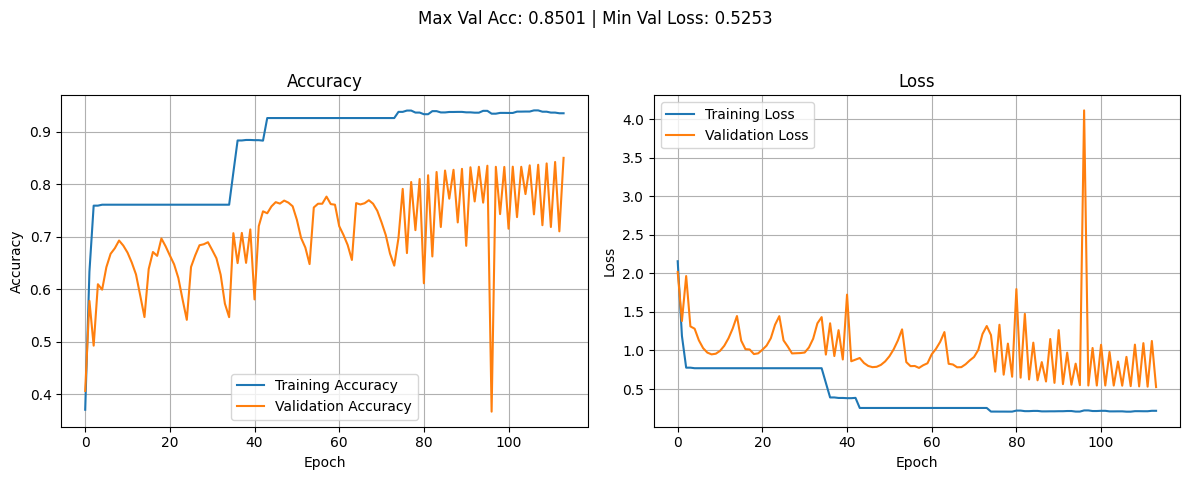

In [ ]:
plot_history(history)

In [ ]:
model = get_best_model(current_x_val, current_x_test)

validação
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8834 - loss: 0.5083

Acurácia da CNN no conjunto: 0.8834


teste
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8744 - loss: 0.4670

Acurácia da CNN no conjunto: 0.8744


In [ ]:
#CNN PADRÃO
def make_model(inputs):

  # x = layers.RandomFlip()(inputs)
  # x = layers.RandomRotation(factor=0.5)(x)

  # x = layers.RandomGaussianBlur(factor=0.01, value_range=(-0.5,0.5))(x)

  x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.Conv2D(64, (3, 3), activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.Conv2D(128, (3, 3), activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)

  x = layers.Dense(256, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=outputs)
  return model

current_x_train, current_x_val, current_x_test, current_x_all = get_current_data_cnn()

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback, reduce_lr = get_model_checkpoint_callback(checkpoint_filepath)

#0.8794

In [ ]:

def layer(x, filters=32, kernel_size_list=[5,7, 9]):
  filters = int(filters / len(kernel_size_list))
  outs = [layers.Conv2D(filters, (i, i), activation='relu', padding="same")(x) for i in kernel_size_list]
  outs = layers.Concatenate()(outs)
  return outs

def make_model(inputs):
  x = layer(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layer(x, 64)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layer(x, 128)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)

  x = layers.Dense(256, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=outputs)
  return model

current_x_test = x_test_cnn

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback, reduce_lr = get_model_checkpoint_callback(checkpoint_filepath)


#0.9078


In [ ]:

def layer(x, filters=32, kernel_size_list=[5,7, 9], conv_class=layers.Conv2D):
  filters = int(filters / len(kernel_size_list))
  outs = [conv_class(filters, (i, i), activation='relu', padding="same")(x) for i in kernel_size_list]
  outs = layers.Concatenate()(outs)
  return outs

def block(inputs, filters=32, kernel_size_list=[5,7, 9], conv_class=layers.Conv2D):
  filters = int(filters / len(kernel_size_list)) * len(kernel_size_list)

  x = layer(inputs, filters, kernel_size_list, conv_class)
  # x = layer(x, filters, kernel_size_list)
  x2 = layers.Conv2D(filters, (1, 1), activation='relu', padding="same")(inputs)
  x = layers.Add()([x,x2])
  x = layers.BatchNormalization()(x)
  return x

def make_model(inputs):
  x = inputs
  x = block(x, 32, conv_class=layers.Conv2D)
  x = block(x, 32, conv_class=layers.SeparableConv2D)
  x = layers.MaxPooling2D((2, 2))(x)

  x = block(x, 64, conv_class=layers.Conv2D)
  x = block(x, 64, conv_class=layers.SeparableConv2D)
  x = layers.MaxPooling2D((2, 2))(x)

  x = block(x, 128,  conv_class=layers.Conv2D)
  x = block(x, 128,  conv_class=layers.SeparableConv2D)
  x = layers.GlobalAveragePooling2D()(x)

  x = layers.Dense(256, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=outputs)
  return model

current_x_train, current_x_val, current_x_test, current_x_all = get_current_data_cnn()

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback, reduce_lr = get_model_checkpoint_callback(checkpoint_filepath)

#0.9392

In [ ]:
import tensorflow as tf
from keras import layers, models, Input
from keras.callbacks import ModelCheckpoint


def make_model(inputs):

    x = layers.SeparableConv2D(32, (3, 3), activation='relu', padding="same")(inputs)
    x = layers.SeparableConv2D(32, (3, 3), activation='relu', padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.SeparableConv2D(64, (3, 3), activation='relu', padding="same")(x)
    x = layers.SeparableConv2D(64, (3, 3), activation='relu', padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.SeparableConv2D(128, (3, 3), activation='relu', padding="same")(x)
    x = layers.SeparableConv2D(128, (3, 3), activation='relu', padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

current_x_test = x_test_cnn

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback, reduce_lr = get_model_checkpoint_callback(checkpoint_filepath)


In [ ]:
import tensorflow as tf
from keras import layers, models, Input
from keras.callbacks import ModelCheckpoint

def residual_block(x, filters, kernel_size=(3, 3), stride=1, activate_before_res=False):
    """
    Um bloco residual que pode ser usado para construir uma ResNet.
    """
    # A função de identidade passa a entrada sem modificações
    shortcut = x

    # Camada de normalização e ativação antes do bloco convolucional, se especificado
    if activate_before_res:
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

    # Primeira convolução
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Segunda convolução
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    # Se as dimensões da entrada e saída do atalho não corresponderem (por causa do stride),
    # fazemos uma convolução 1x1 no atalho para corresponder às dimensões.
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same', kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Adiciona o atalho à saída do bloco e aplica a ativação final
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def make_model(inputs):

      # Camada de entrada
      x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
      x = layers.BatchNormalization()(x)
      x = layers.Activation('relu')(x)
      x = layers.MaxPooling2D((2, 2))(x)

      # Blocos Residuais
      x = residual_block(x, 64) # Bloco sem downsampling
      x = residual_block(x, 64) # Outro bloco sem downsampling
      x = residual_block(x, 128, stride=2) # Bloco com downsampling
      x = residual_block(x, 128)

      # x = residual_block(x, 32)
      # x = residual_block(x, 32)
      # x = residual_block(x, 32)
      # x = residual_block(x, 32)

      # Camada final de pooling e classificação
      x = layers.GlobalAveragePooling2D()(x)

      x = layers.Dense(256, activation='relu')(x)
      x = layers.Dropout(0.5)(x)
      outputs = layers.Dense(num_classes, activation='softmax')(x)

      model = models.Model(inputs=inputs, outputs=outputs)
      return model

current_x_test = x_test_cnn

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback = get_model_checkpoint_callback(checkpoint_filepath)



In [ ]:
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input
from keras import layers, models
import numpy as np


def make_model(inputs):
  base_model = VGG16(weights='imagenet', include_top=False, input_tensor=inputs, name="base_model")
  base_model.trainable = False

  x = base_model(inputs)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(256, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  x = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=x)
  return model


current_x_train, current_x_val, current_x_test, current_x_all = get_current_data_transfer(preprocess_input)

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model, num_colors=3)

model_checkpoint_callback, reduce_lr = get_model_checkpoint_callback(checkpoint_filepath)

In [ ]:
fit(model_temp, current_x_train, current_x_val, history, epochs=30, steps=1)

In [ ]:
1/30

In [ ]:
plot_history(history)

In [ ]:
plot_history(history)

In [ ]:
plot_history(history)

In [ ]:
model = get_best_model(current_x_val, current_x_test)

In [ ]:
show_model_predictions(model, current_x_test)

In [ ]:
cm_normalized = get_confusion_matrix_normalized(model, current_x_test)
plot_confusion_matrix(cm_normalized)

In [ ]:
min_acc_idx, min_acc_class_name, min_acc = get_min_acc_class(cm_normalized)
plot_class_acc_distribution(cm_normalized)

In [ ]:
show_min_acc_distribution(cm_normalized, min_acc_idx, min_acc_class_name, min_acc)

In [ ]:
model_heatmap = get_heatmap_model(model, current_x_all)
display_heatmaps(current_x_all, x_raw, y_all, model_heatmap)

In [ ]:
base = next(i for i in model_temp.layers if i.name == "base_model")
base.trainable = True

In [ ]:
import tensorflow as tf
from keras import layers, models


model = models.Sequential([
    layers.Flatten(input_shape=x_dims),          # Transforma a imagem 28x28 em um vetor de 784 pixels
    layers.Dense(128, activation='relu'),          # Camada oculta com 128 neurônios
    layers.Dropout(0.2),                           # Camada de regularização para evitar overfitting
    layers.Dense(y_dims, activation='softmax')         # Camada de saída com 10 neurônios (0 a 9)
])

# 3. Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Treinar o modelo
model.fit(x_train_norm, y_train_norm, epochs=5)

model.evaluate(x_test_norm, y_test_norm)

In [ ]:
import tensorflow as tf
from keras import layers, models
from keras.applications.convnext import preprocess_input, ConvNeXtBase
import keras

x_train_transfer_raw = np.repeat(x_train_balanced[..., np.newaxis], 3, -1)
x_test_transfer_raw = np.repeat(x_test_balanced[..., np.newaxis], 3, -1)

x_train_transfer = preprocess_input(x_train_transfer_raw.astype('float32'))
x_test_transfer = preprocess_input(x_test_transfer_raw.astype('float32'))
y_train_transfer = y_train_balanced
y_test_transfer = y_test_balanced

x_transfer_dim = x_train_transfer.shape[1:]
# Carrega o ConvNeXtBase sem o topo, com pesos ImageNet
base_model = ConvNeXtBase(
    include_top=False,
    weights='imagenet',
    input_shape=x_transfer_dim,
    pooling='avg'  # adiciona global average pooling no lugar do topo
)

# Congela a base
base_model.trainable = False

# Adiciona suas camadas de classificação
model = models.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(y_dims, activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("--- Treinando Transfer Learning com preprocess_input correto ---")
model.fit(x_train_transfer, y_train_transfer, epochs=15, batch_size=32, validation_data=(x_test_transfer, y_test_transfer))

# Avaliação final
loss, acc = model.evaluate(x_test_transfer, y_test_transfer)
print(f"\nAcurácia final com transfer16: {acc:.4f}")